# S18 — Engine vs SFM, graded against the engineers

**Question:** across every TCB part in all 8 monthly BOM-review snapshots, does the
statistical engine reproduce the engineer's decision more often than the SFM
recommendation already sitting in the workbook?

| role | columns |
|---|---|
| truth (engineer) | `factory_recommended_new_max / rop / min` |
| baseline (SFM) | `sfm_max / sfm_rop / sfm_min` (+ label `sfm_recommendation`) |
| challenger (engine) | `engine_statistical.run()` output |

**Match rule** — `common.agree()`, the same predicate s15/s17 use:
`|proposed − engineer| <= max(1, 10% * |engineer|)` on **all three** levels.
Same row, same rule, both candidates — so the two match rates are comparable.

The engine reads `factory_recommended_new_*` only *after* sizing (agreement flag);
it never enters the sizing maths, so there is no leakage into the number graded here.

In [ ]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "backend").is_dir())
sys.path[:0] = [str(ROOT / "analysis"), str(ROOT / "backend" / "app")]

import engine_statistical  # the production sizing engine
from common import LEVELS, OUT, agree, read_module_rows, to_num
from s10_multi_month_extract import resolve_files

pd.set_option("display.width", 160)
print("engine", engine_statistical.MODEL_VERSION, "| levels", LEVELS)

engine stat-v1 | levels ('max', 'rop', 'min')


## 1. Extract every TCB row from all monthly snapshots

Row-level (one row per source line), *not* collapsed to item: SFM and the engineer
both state their numbers at that grain, so grading there keeps the three columns on
the same footing.

**First run is slow, and one file dominates.** `Dec_24 BOM REVIEW.xlsx` is 340 MB on
disk but 2.7 GB of uncompressed sheet XML — Excel's used-range blowout, millions of
styled-but-empty cells wrapped around 2,748 real TCB rows. `common.read_module_rows`
streams it in a single read-only pass (`pd.read_excel` would materialise every one of
those cells, twice, because the `nrows=` header probe pays the same cost). Expect a
few minutes on that one file and seconds on the rest. The result is cached — delete
`analysis/output/s18_month_panel.csv` to force a re-extract.

In [ ]:
PANEL = OUT / "s18_month_panel.csv"

FAC = [f"factory_recommended_new_{lvl}" for lvl in LEVELS]
SFM = [f"sfm_{lvl}" for lvl in LEVELS]
ENGINE_IN = list(engine_statistical.CONS.values()) + [
    "contractual_lead_time", "order_qty_multiple", "unitprice",
    "max_qty", "rop_qty", "min_qty", "frequencymonthswithusage",
    "sfm_mean_lt_cd", "qry_eoh_excess_qty",
]
TEXT = ["item_id", "item_desc", "stockroom_id", "sfm_criticality", "ownership",
        "sfm_recommendation"]
KEEP = TEXT + ENGINE_IN + FAC + SFM


def load_month(path: Path, year: int, month: int, sheet: str | None) -> pd.DataFrame:
    """TCB rows of one snapshot, typed, with any absent column created as NaN."""
    out = read_module_rows(path, sheet, KEEP)
    for c in TEXT:
        out[c] = out[c].astype("string").str.strip().replace("", pd.NA)
    for c in ENGINE_IN + FAC + SFM:
        out[c] = to_num(out[c])
    out.insert(0, "month", f"{year:04d}-{month:02d}")
    return out


if PANEL.exists():
    panel = pd.read_csv(PANEL, dtype={c: str for c in TEXT}, encoding="utf-8-sig")
    print(f"loaded cache {PANEL.name}")
else:
    frames = []
    for path, y, m, sheet in resolve_files():
        t = time.perf_counter()
        f = load_month(path, y, m, sheet)
        frames.append(f)
        print(f"  {y}-{m:02d}  {len(f):5,} TCB rows  "
              f"{time.perf_counter() - t:6.1f}s  {path.name[:38]}", flush=True)
    panel = pd.concat(frames, ignore_index=True)
    panel.to_csv(PANEL, index=False, encoding="utf-8-sig")
    print(f"wrote cache {PANEL.name}  (delete it to re-extract)")

print()
print(f"{len(panel):,} TCB rows across {panel['month'].nunique()} months")
panel.groupby("month").agg(rows=("item_id", "size"), items=("item_id", "nunique"))

loaded cache s18_month_panel.csv

9,451 TCB rows across 8 months


,rows,items
month,,
2024-07,244,225
2024-08,154,147
2024-09,2500,2500
2024-10,730,730
2024-12,2748,2748
2025-03,140,140
2025-05,155,154
2026-01,2780,2780


## 2. Run the engine on each snapshot

Each month is sized independently, from that month's own trailing-consumption
windows — exactly what the engine would have seen had it run that month.

In [ ]:
frames = []
for month, g in panel.groupby("month", sort=True):
    g = g.reset_index(drop=True)
    res = engine_statistical.run(g)
    frames.append(g.assign(
        **{f"eng_{lvl}": res[f"factory_recommended_new_{lvl}"].to_numpy()
           for lvl in LEVELS},
        eng_review=res["review_required"].to_numpy(),
        eng_route=res["route"].to_numpy(),
    ))
    print(f"  {month}: sized {len(g):,} rows")

df = pd.concat(frames, ignore_index=True)
print(f"\nscored {len(df):,} rows")

  2024-07: sized 244 rows


  2024-08: sized 154 rows


  2024-09: sized 2,500 rows


  2024-10: sized 730 rows


  2024-12: sized 2,748 rows
  2025-03: sized 140 rows
  2025-05: sized 155 rows


  2026-01: sized 2,780 rows

scored 9,451 rows


## 3. Grade both candidates against the engineer

A row is **gradable** only when the engineer filled all three levels *and* SFM
filled all three — otherwise one side would be scored on rows the other never
answered. Same denominator for both.

In [ ]:
fac = {lvl: df[f"factory_recommended_new_{lvl}"].to_numpy(float) for lvl in LEVELS}

df["labelled"] = np.all([~np.isnan(fac[lvl]) for lvl in LEVELS], axis=0)
df["sfm_present"] = np.all([df[f"sfm_{lvl}"].notna().to_numpy() for lvl in LEVELS], axis=0)
df["gradable"] = df["labelled"] & df["sfm_present"]

df["engine_match"] = np.all(
    [agree(df[f"eng_{lvl}"].to_numpy(float), fac[lvl]) for lvl in LEVELS], axis=0)
df["sfm_match"] = np.all(
    [agree(df[f"sfm_{lvl}"].to_numpy(float), fac[lvl]) for lvl in LEVELS], axis=0)

print(f"engineer-labelled rows : {df['labelled'].sum():,} / {len(df):,}")
print(f"gradable (both answer) : {df['gradable'].sum():,}")
df.to_csv(OUT / "s18_engine_vs_sfm_rows.csv", index=False, encoding="utf-8-sig")

engineer-labelled rows : 9,105 / 9,451
gradable (both answer) : 2,265


In [ ]:
g = df[df["gradable"]]

card = (g.groupby("month")
         .agg(rows=("engine_match", "size"),
              engine_matched=("engine_match", "sum"),
              sfm_matched=("sfm_match", "sum"))
         .reset_index())
card.loc[len(card)] = ["ALL", len(g), g["engine_match"].sum(), g["sfm_match"].sum()]
card["engine_%"] = (100 * card["engine_matched"] / card["rows"]).round(1)
card["sfm_%"] = (100 * card["sfm_matched"] / card["rows"]).round(1)
card["delta_pp"] = (card["engine_%"] - card["sfm_%"]).round(1)

card.to_csv(OUT / "s18_engine_vs_sfm_by_month.csv", index=False, encoding="utf-8-sig")
card

,month,rows,engine_matched,sfm_matched,engine_%,sfm_%,delta_pp
0,2024-07,43,34,33,79.1,76.7,2.4
1,2024-08,9,4,3,44.4,33.3,11.1
2,2024-09,586,533,549,91.0,93.7,-2.7
3,2024-10,165,115,103,69.7,62.4,7.3
4,2024-12,655,589,561,89.9,85.6,4.3
5,2025-03,71,37,64,52.1,90.1,-38.0
6,2025-05,80,48,65,60.0,81.2,-21.2
7,2026-01,656,564,590,86.0,89.9,-3.9
8,ALL,2265,1924,1968,84.9,86.9,-2.0


## 4. Which denominator? (reconciling with the earlier validation)

The earlier engine-vs-engineer scorecard and this notebook disagree at first glance
(95.0% there, 84.9% here). They are measuring different row sets, not different
engines. Three denominators are in play:

| set | meaning | who reports it |
|---|---|---|
| `ingested` | every TCB row in the snapshot | both, and they agree exactly |
| `labelled` | engineer filled all three levels | earlier table's **Benchmarked** |
| `gradable` | ...**and** SFM filled all three too | this notebook's head-to-head |

`labelled` runs a few rows above the earlier **Benchmarked** because that pipeline's
`ingest()` drops a handful per batch (its Ingested to Scored step); this extract does
not dedupe. The engine's rate on `labelled` reproduces the earlier table.

`gradable` is a strictly harder subset: SFM stays silent on the dormant book, where
the engineer wrote 0/0/0 and the engine trivially agrees. So the head-to-head is
fought on the contested quarter of the parts, and the engine's coverage advantage on
the other three quarters is invisible in it - hence both views on the chart.

In [ ]:
recon = []
for month, m in df.groupby("month"):
    lab, gr = m[m["labelled"]], m[m["gradable"]]
    recon.append({
        "month": month,
        "ingested": len(m),
        "labelled": len(lab),
        "engine_%_labelled": round(100 * lab["engine_match"].mean(), 1) if len(lab) else np.nan,
        "sfm_answered": int(m["sfm_present"].sum()),
        "gradable": len(gr),
        "sfm_coverage_%": round(100 * len(gr) / len(lab), 1) if len(lab) else np.nan,
        "engine_%_gradable": round(100 * gr["engine_match"].mean(), 1) if len(gr) else np.nan,
        "sfm_%_gradable": round(100 * gr["sfm_match"].mean(), 1) if len(gr) else np.nan,
    })

lab_all = df[df["labelled"]]
recon.append({
    "month": "ALL",
    "ingested": len(df),
    "labelled": len(lab_all),
    "engine_%_labelled": round(100 * lab_all["engine_match"].mean(), 1),
    "sfm_answered": int(df["sfm_present"].sum()),
    "gradable": int(df["gradable"].sum()),
    "sfm_coverage_%": round(100 * df["gradable"].sum() / len(lab_all), 1),
    "engine_%_gradable": round(100 * g["engine_match"].mean(), 1),
    "sfm_%_gradable": round(100 * g["sfm_match"].mean(), 1),
})
recon = pd.DataFrame(recon)
recon.to_csv(OUT / "s18_denominator_reconciliation.csv", index=False, encoding="utf-8-sig")

silent = lab_all[~lab_all["sfm_present"]]
print(f"engineer-labelled, SFM answered : {int(df['gradable'].sum()):5,} rows, "
      f"engine {100 * g['engine_match'].mean():.1f}%")
print(f"engineer-labelled, SFM silent   : {len(silent):5,} rows, "
      f"engine {100 * silent['engine_match'].mean():.1f}%")
print("SFM offers no number at all on the second set.")
recon

engineer-labelled, SFM answered : 2,265 rows, engine 84.9%
engineer-labelled, SFM silent   : 6,840 rows, engine 98.6%
SFM offers no number at all on the second set.


,month,ingested,labelled,engine_%_labelled,sfm_answered,gradable,sfm_coverage_%,engine_%_gradable,sfm_%_gradable
0,2024-07,244,138,93.5,110,43,31.2,79.1,76.7
1,2024-08,154,9,44.4,127,9,100.0,44.4,33.3
2,2024-09,2500,2500,97.7,586,586,23.4,91.0,93.7
3,2024-10,730,730,93.2,165,165,22.6,69.7,62.4
4,2024-12,2748,2653,96.8,669,655,24.7,89.9,85.6
5,2025-03,140,140,75.0,71,71,50.7,52.1,90.1
6,2025-05,155,155,76.1,80,80,51.6,60.0,81.2
7,2026-01,2780,2780,94.2,656,656,23.6,86.0,89.9
8,ALL,9451,9105,95.2,2464,2265,24.9,84.9,86.9


## 5. The graph

Match rate against the historical engineer decision, per snapshot month.

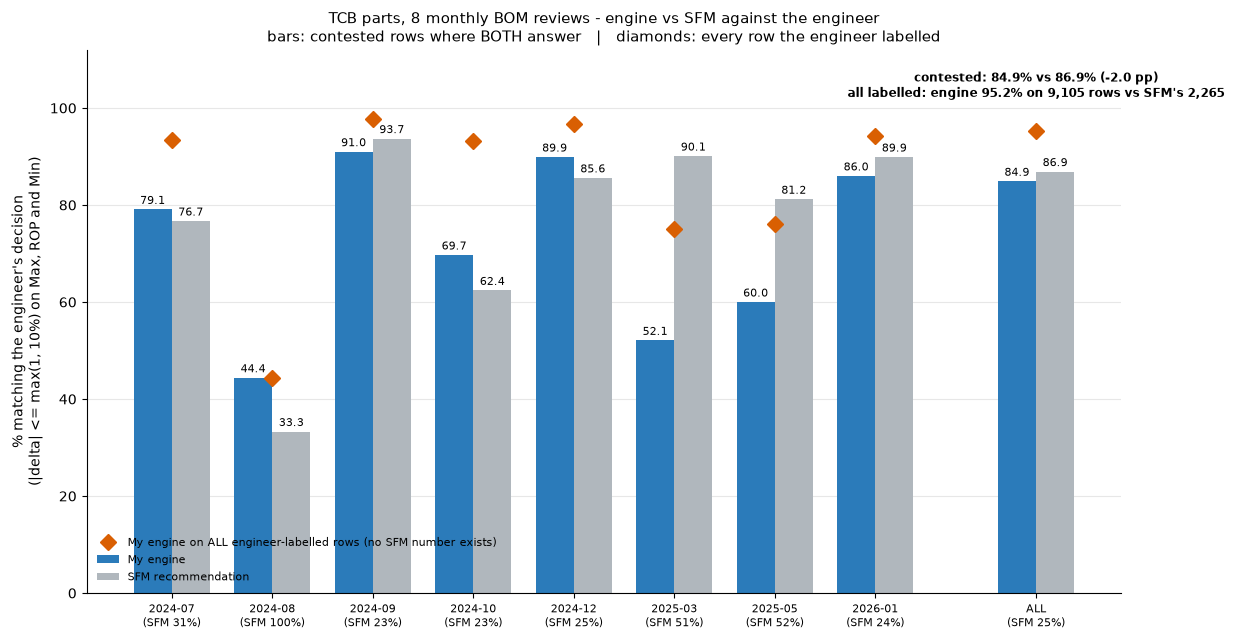

In [ ]:
months = card["month"].tolist()
x = np.arange(len(months), dtype=float)
x[-1] += 0.6                                   # gap before the ALL column
w = 0.38

by_month = recon.set_index("month")
lab_rate = by_month["engine_%_labelled"]
cover = by_month["sfm_coverage_%"]

fig, ax = plt.subplots(figsize=(12.5, 6.5))
b1 = ax.bar(x - w / 2, card["engine_%"], w, label="My engine", color="#2b7bba")
b2 = ax.bar(x + w / 2, card["sfm_%"], w, label="SFM recommendation", color="#b0b7bd")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

# The engine also answers the rows SFM leaves blank; show that rate so the
# head-to-head is not mistaken for the engine's overall accuracy.
ax.plot(x, [lab_rate[m] for m in months], "D", ms=8, color="#d95f02", lw=0,
        label="My engine on ALL engineer-labelled rows (no SFM number exists)")

ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n(SFM {cover[m]:.0f}%)" for m in months], fontsize=8)
ax.set_ylabel("% matching the engineer's decision\n(|delta| <= max(1, 10%) on Max, ROP and Min)")
ax.set_title("TCB parts, 8 monthly BOM reviews - engine vs SFM against the engineer\n"
             "bars: contested rows where BOTH answer   |   diamonds: every row the engineer labelled",
             fontsize=11)
ax.set_ylim(0, 112)
ax.legend(frameon=False, loc="lower left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

n = card.loc[card["month"] == "ALL"].iloc[0]
ax.annotate(f"contested: {n['engine_%']:.1f}% vs {n['sfm_%']:.1f}% ({n['delta_pp']:+.1f} pp)\n"
            f"all labelled: engine {lab_rate['ALL']:.1f}% on "
            f"{int(by_month.loc['ALL', 'labelled']):,} rows vs SFM's "
            f"{int(by_month.loc['ALL', 'gradable']):,}",
            xy=(x[-1], 100), xytext=(0, 8), textcoords="offset points",
            ha="center", fontsize=8.5, fontweight="bold")

fig.tight_layout()
fig.savefig(OUT / "s18_engine_vs_sfm.png", dpi=150)
plt.show()

## 6. Verdict

In [ ]:
per_month = card[card["month"] != "ALL"]
won = int((per_month["delta_pp"] > 0).sum())
total = n["engine_%"] - n["sfm_%"]

print(f"contested rows  : engine {n['engine_%']:.1f}% vs SFM {n['sfm_%']:.1f}% "
      f"({total:+.1f} pp) on {int(n['rows']):,} rows; engine wins {won}/{len(per_month)} months")
print(f"coverage        : engine answers {int(by_month.loc['ALL', 'labelled']):,} "
      f"engineer-labelled rows at {lab_rate['ALL']:.1f}%; "
      f"SFM answers {int(by_month.loc['ALL', 'gradable']):,}")
print()
print("verdict: on the rows both systems answer, SFM is marginally closer to the")
print("engineers; on the other three quarters of the book SFM proposes nothing.")

# where they disagree with each other -- the rows worth eyeballing
split = g.groupby(["engine_match", "sfm_match"]).size().rename("rows")
print("\nengine_match x sfm_match:")
print(split.to_string())

contested rows  : engine 84.9% vs SFM 86.9% (-2.0 pp) on 2,265 rows; engine wins 4/8 months
coverage        : engine answers 9,105 engineer-labelled rows at 95.2%; SFM answers 2,265

verdict: on the rows both systems answer, SFM is marginally closer to the
engineers; on the other three quarters of the book SFM proposes nothing.

engine_match x sfm_match:
engine_match  sfm_match
False         False         114
              True          227
True          False         183
              True         1741


### Per-level detail (optional)

The headline rule is strict — all three levels at once. This splits it out so a
single stubborn level (usually Min) does not hide agreement on the rest.

In [ ]:
rows = []
for lvl in LEVELS:
    truth = g[f"factory_recommended_new_{lvl}"].to_numpy(float)
    rows.append({
        "level": lvl,
        "engine_%": round(100 * agree(g[f"eng_{lvl}"].to_numpy(float), truth).mean(), 1),
        "sfm_%": round(100 * agree(g[f"sfm_{lvl}"].to_numpy(float), truth).mean(), 1),
    })
pd.DataFrame(rows)

,level,engine_%,sfm_%
0,max,87.0,87.2
1,rop,90.9,90.7
2,min,91.7,97.7
